Bài 1: 
Chọn ảnh quả kiwi bất kì .
Tịnh tiến quả kiwi 50 pixel sang phải và 30 pixel xuống dưới.
Áp dụng hiệu ứng sóng (wave effect) lên quả kiwi bằng cách sử dụng biến đổi tọa độ (map_coordinates) với hàm sin.
Lưu ảnh kết quả vào file kiwi_wave.jpg

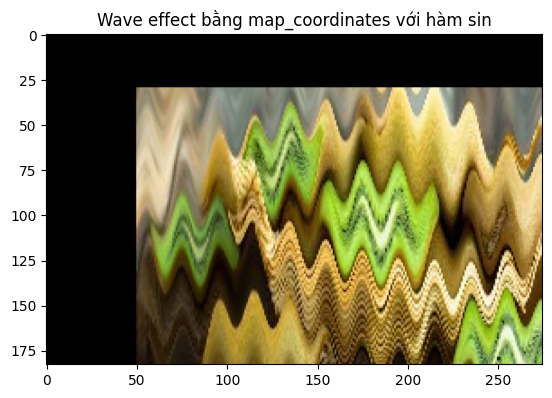

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import scipy.ndimage as nd
data = iio.imread("images/kiwi.jpg")
V, H = data.shape[:2]
M = np.indices((V, H))
a = 10
f = 20
map_y = M[0] + a * np.sin(2 * np.pi * M[1] / f)
map_x = M[1]
coords = np.array([map_y, map_x])
result = np.zeros_like(data)
for c in range(data.shape[2]):
    result[..., c] = nd.map_coordinates(data[..., c], coords, order=1, mode='reflect')
shifted = nd.shift(result, (30, 50, 0))
iio.imsave("images/kiwi_wave.jpg", shifted.astype(np.uint8))
plt.title("Wave effect bằng map_coordinates với hàm sin")
plt.imshow(shifted)
plt.show()

Bài 2: 
Chọn quả đu đủ và dưa hấu từ google.
Đổi màu đu đủ thành gradient từ đỏ sang xanh lá, và dưa hấu thành gradient từ vàng sang tím.
Ghép hai quả lên một nền trong suốt (alpha channel) và lưu dưới dạng PNG.

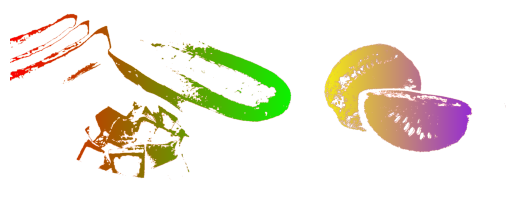

In [ ]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

img_papaya = iio.imread("images/du-du.webp")
img_watermelon = iio.imread("images/dua-hau.webp")

r, g, b = img_papaya[..., 0], img_papaya[..., 1], img_papaya[..., 2]
is_papaya = (r > 200) & (g > 100) & (b < 100)
h1, w1 = r.shape
grad_papaya = np.linspace(0, 1, w1)
grad_papaya = np.tile(grad_papaya, (h1, 1))
papaya_new = img_papaya.copy()
papaya_new = papaya_new.astype(float)
papaya_new[..., 0][is_papaya] = (1 - grad_papaya[is_papaya]) * 255
papaya_new[..., 1][is_papaya] = grad_papaya[is_papaya] * 255
papaya_new[..., 2][is_papaya] = 0
alpha_papaya = np.zeros((h1, w1), dtype=np.uint8)
alpha_papaya[is_papaya] = 255

r, g, b = img_watermelon[..., 0], img_watermelon[..., 1], img_watermelon[..., 2]
is_watermelon = (r > 150) & (g < 100) & (b < 100)
h2, w2 = r.shape
grad_watermelon = np.linspace(0, 1, w2)
grad_watermelon = np.tile(grad_watermelon, (h2, 1))
watermelon_new = img_watermelon.copy()
watermelon_new = watermelon_new.astype(float)
watermelon_new[..., 0][is_watermelon] = 255 * (1 - grad_watermelon[is_watermelon] * 0.5)
watermelon_new[..., 1][is_watermelon] = 255 * (1 - grad_watermelon[is_watermelon])
watermelon_new[..., 2][is_watermelon] = 255 * grad_watermelon[is_watermelon]
alpha_watermelon = np.zeros((h2, w2), dtype=np.uint8)
alpha_watermelon[is_watermelon] = 255

H = max(h1, h2)
W = w1 + w2 + 20 
canvas = np.zeros((H, W, 4), dtype=np.uint8)

canvas[:h1, :w1, :3] = papaya_new[..., :3].astype(np.uint8)
canvas[:h1, :w1, 3] = alpha_papaya

canvas[:h2, w1+20:w1+20+w2, :3] = watermelon_new[..., :3].astype(np.uint8)
canvas[:h2, w1+20:w1+20+w2, 3] = alpha_watermelon

iio.imwrite("images/fruit_gradient_composite.png", canvas)
plt.imshow(canvas)
plt.axis('off')
plt.show()

Bài 3: 
Chọn ảnh núi và thuyền.
Xoay cả hai đối tượng 45 độ, giữ kích thước ban đầu (reshape=False).
Tạo hiệu ứng phản chiếu dọc (vertical mirror) cho cả hai đối tượng sau khi xoay.
Ghép cả hai đối tượng lên một canvas trắng và lưu vào mountain_boat_mirror.jpg

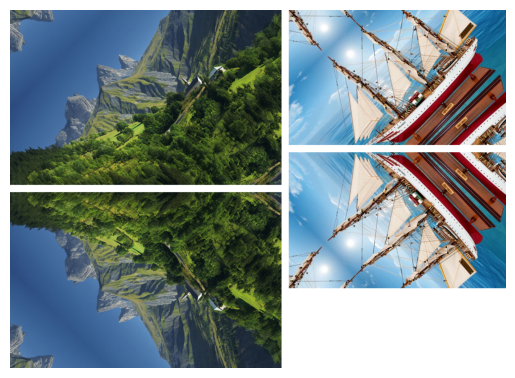

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import scipy.ndimage as nd

img_mountain = iio.imread("images/mountain.jpg")
img_boat = iio.imread("images/boat.jpg")  

mountain_rot = nd.rotate(img_mountain, 45, reshape=False, order=1, mode='reflect')
boat_rot = nd.rotate(img_boat, 45, reshape=False, order=1, mode='reflect')

mountain_mirror = np.flipud(mountain_rot)
boat_mirror = np.flipud(boat_rot)

h1, w1 = mountain_rot.shape[:2]
h2, w2 = boat_rot.shape[:2]

canvas_h = max(h1, h2) * 2 + 20
canvas_w = w1 + w2 + 20
canvas = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255

canvas[:h1, :w1, :] = mountain_rot
canvas[h1+20:h1*2+20, :w1, :] = mountain_mirror

canvas[:h2, w1+20:w1+20+w2, :] = boat_rot
canvas[h2+20:h2*2+20, w1+20:w1+20+w2, :] = boat_mirror

iio.imwrite("images/mountain_boat_mirror.jpg", canvas)
plt.imshow(canvas)
plt.axis('off')
plt.show()


Bài 4: 
Chọn ngôi chùa bất kì.
Phóng to ngôi chùa lên 5 lần.
Áp dụng một biến đổi hình học tùy chỉnh (geometric transform) để tạo hiệu ứng "uốn cong" (warping) ngôi chùa.
Lưu ảnh kết quả vào pagoda_warped.jpg.

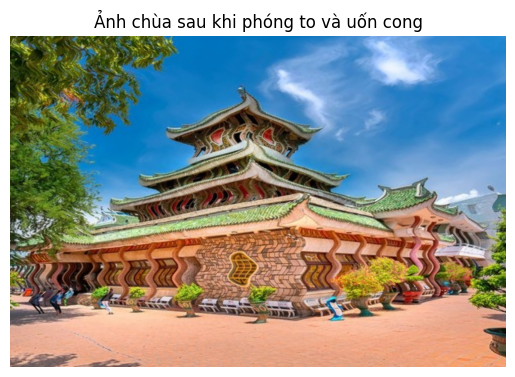

In [ ]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import scipy.ndimage as nd

img = iio.imread("images/pagoda.jpg")

zoomed = nd.zoom(img, (5, 5, 1), order=1)

h, w = zoomed.shape[:2]

Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')

X_warped = X + 20 * np.sin(2 * np.pi * Y / 150)
Y_warped = Y

coords = [Y_warped.ravel(), X_warped.ravel()]

warped_img = np.zeros_like(zoomed)
for i in range(3):  
    warped_img[..., i] = nd.map_coordinates(zoomed[..., i], coords, order=1, mode='reflect').reshape((h, w))

iio.imwrite("images/pagoda_warped.jpg", warped_img)

plt.imshow(warped_img)
plt.axis('off')
plt.title("Ảnh chùa sau khi phóng to 5 lần và uốn cong")
plt.show()


Bài 5:
Tạo một chương trình menu tương tác cho phép người dùng chọn các phép biến đổi sau:
Tịnh tiến (hỏi số pixel di chuyển theo x và y).
Xoay (hỏi góc xoay và chọn reshape=True/False).
Phóng to/thu nhỏ (hỏi hệ số zoom).
Làm mờ Gaussian (hỏi giá trị sigma).
Biến đổi sóng (hỏi biên độ sóng).
Người dùng chọn ảnh từ 3 ảnh bất kì

Chọn một ảnh:
1. boat.jpg
2. fruit.jpg
3. pagoda.jpg

Chọn phép biến đổi:
1. Tịnh tiến
2. Xoay
3. Phóng to/thu nhỏ
4. Làm mờ Gaussian
5. Biến dạng sóng
Ảnh đã lưu vào images/output.jpg


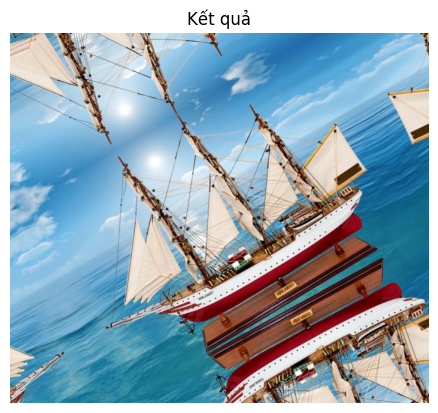

In [8]:
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pyplot as plt

def choose_image():
    print("Chọn một ảnh:")
    print("1. boat.jpg")
    print("2. fruit.jpg")
    print("3. pagoda.jpg")
    choice = input("Nhập lựa chọn (1-3): ")
    filenames = {
        "1": "images/boat.jpg",
        "2": "images/fruit.jpg",
        "3": "images/pagoda.jpg"
    }
    return iio.imread(filenames.get(choice, "images/boat.jpg"))

def translate_image(img):
    dx = int(input("Nhập số pixel tịnh tiến theo X: "))
    dy = int(input("Nhập số pixel tịnh tiến theo Y: "))
    return nd.shift(img, shift=(dy, dx, 0), order=1, mode='reflect')

def rotate_image(img):
    angle = float(input("Nhập góc xoay (độ): "))
    reshape = input("Giữ nguyên kích thước? (y/n): ").strip().lower() != 'n'
    return nd.rotate(img, angle=angle, reshape=reshape, order=1, mode='reflect')

def zoom_image(img):
    factor = float(input("Nhập hệ số phóng to (>1) hoặc thu nhỏ (<1): "))
    return nd.zoom(img, zoom=(factor, factor, 1), order=1)

def gaussian_blur(img):
    sigma = float(input("Nhập giá trị sigma cho Gaussian blur: "))
    return nd.gaussian_filter(img, sigma=(sigma, sigma, 0))

def wave_warp(img):
    amplitude = float(input("Nhập biên độ sóng: "))
    h, w = img.shape[:2]
    Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    X_new = X + amplitude * np.sin(2 * np.pi * Y / 150)
    Y_new = Y
    coords = [Y_new.ravel(), X_new.ravel()]
    warped = np.zeros_like(img)
    for i in range(3):
        warped[..., i] = nd.map_coordinates(img[..., i], coords, order=1, mode='reflect').reshape(h, w)
    return warped

def main():
    img = choose_image()

    print("\nChọn phép biến đổi:")
    print("1. Tịnh tiến")
    print("2. Xoay")
    print("3. Phóng to/thu nhỏ")
    print("4. Làm mờ Gaussian")
    print("5. Biến dạng sóng")

    option = input("Nhập lựa chọn (1-5): ")

    if option == "1":
        result = translate_image(img)
    elif option == "2":
        result = rotate_image(img)
    elif option == "3":
        result = zoom_image(img)
    elif option == "4":
        result = gaussian_blur(img)
    elif option == "5":
        result = wave_warp(img)
    else:
        print("Lựa chọn không hợp lệ. Thoát.")
        return

    iio.imwrite("images/output.jpg", result)
    print("Ảnh đã lưu vào images/output.jpg")

    plt.imshow(result)
    plt.axis('off')
    plt.title("Kết quả")
    plt.show()

if __name__ == "__main__":
    main()
